# Latent world model — evaluation

In [ ]:
import json
from pathlib import Path

from koopman_control.paths import dataset_path, output_root

# Resolve the repo root for relative paths stored by older local runs.
ROOT = Path.cwd()
while not (ROOT / "pyproject.toml").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent

# These respect KOOPMAN_DATA_ROOT, KOOPMAN_OUTPUT_ROOT
DATASET = dataset_path()
OUTPUT_ROOT = output_root()

# Select exactly one model source. RUN_DIR points to a standalone training run;
# set it to None and set STUDY_DIR to evaluate an Optuna search result instead.
RUN_DIR = OUTPUT_ROOT / "training/20260730-121221"
STUDY_DIR = None  # e.g. OUTPUT_ROOT / "search/linear-vs-bilinear-h20"

if RUN_DIR is not None:
    RUN_DIR = Path(RUN_DIR)
    CKPT = max(
        (RUN_DIR / "checkpoints").glob("*.ckpt"),
        key=lambda p: p.stat().st_mtime,
    )
    METRICS = RUN_DIR / "logs/metrics.csv"
elif STUDY_DIR is not None:
    STUDY_DIR = Path(STUDY_DIR)
    selection = json.loads((STUDY_DIR / "best_model.json").read_text())
    CKPT = STUDY_DIR / "best_model.ckpt"
    selected_checkpoint = Path(selection["selected_checkpoint"])
    if not selected_checkpoint.is_absolute():
        selected_checkpoint = ROOT / selected_checkpoint
    METRICS = selected_checkpoint.parent.parent / "logs/metrics.csv"
else:
    raise ValueError("Set RUN_DIR or STUDY_DIR to select a model.")

if not CKPT.exists():
    raise FileNotFoundError(f"Checkpoint not found: {CKPT}")
if not METRICS.exists():
    raise FileNotFoundError(f"Metrics not found: {METRICS}")

# Horizon at which the scorecard is evaluated. Matching the training horizon makes
# the numbers comparable to the logged metrics.
SCORE_HORIZON = 20
# Runs used to fit the linear probes. The full train split is ~500 MB resident.
N_PROBE_TRAIN = 40

print("dataset   :", DATASET)
print("output root:", OUTPUT_ROOT)
print("checkpoint:", CKPT)
print("metrics   :", METRICS)

dataset   : /Users/jacobevarts/BagheriLab/koopman-control/data/rabbit_grass_images/dataset.h5
output root: /Users/jacobevarts/BagheriLab/koopman-control/outputs
checkpoint: /Users/jacobevarts/BagheriLab/koopman-control/outputs/training/20260730-121221/checkpoints/last.ckpt
metrics   : /Users/jacobevarts/BagheriLab/koopman-control/outputs/training/20260730-121221/logs/metrics.csv


## 1. Load and score

One cell does all the expensive work (encoding the held-out splits, fitting the probes
and the reference linear model, sweeping the simulator for dose-response) so every plot
below is instant. Expect roughly half a minute.

In [36]:
%matplotlib inline
import numpy as np

from koopman_control.analysis import evaluate as ev
from koopman_control.analysis import plots as ep

model = ev.load_model(CKPT)
val = ev.load_split_trajectories(DATASET, "val")
test = ev.load_split_trajectories(DATASET, "test")
probe_train = ev.load_split_trajectories(DATASET, "train", N_PROBE_TRAIN)

# Encode once, reuse everywhere.
enc = ev.encode_all(model, val)

# Reference linear model fitted by least squares in this same latent (see section 3).
fitted = ev.fit_latent_linear(model, val, enc=enc)

herr = ev.horizon_errors(model, val, enc=enc, fitted=fitted)
pca = ev.latent_pca(model, val, enc=enc)
probe = ev.linear_probe(model, probe_train, val)
macro = ev.macrostate_correlation(model, val, enc=enc)
modes = ev.mode_analysis(model)
ctrl_sv = ev.controllability_spectrum(model)
dose = ev.dose_response(model, steps=100, seeds=(0, 1, 2))

print(f"dynamics mode : {model.hparams.dynamics_mode}")
print(f"latent dim    : {model.latent_dim}   train horizon: {model.hparams.horizon}")
print(f"held-out runs : {len(val)} val / {len(test)} test, {enc['z'].shape[1]} frames each")
print()
print(ev.format_scorecard(ev.scorecard(
    model=model, herr=herr, probe=probe, pca=pca, modes=modes,
    ctrl_sv=ctrl_sv, dose=dose, macro=macro, fitted=fitted, horizon=SCORE_HORIZON,
)))

dynamics mode : bilinear
latent dim    : 16   train horizon: 20
held-out runs : 84 val / 42 test, 201 frames each

metric                                    value  status  note
-----------------------------------------------------------------
prediction skill @ h=20                  +0.297  [warn]  vs -1.020 for the persistence baseline
beats persistence?                          yes  [ ok ]  a model that loses to a frozen latent has learned no dynamics
rabbit_count linearly decodable          +0.926  [ ok ]  held-out R^2 of a ridge readout from z
control legible in latent                +0.347  [warn]  R^2 predicting the applied u from z alone
latent dimensions in use              11.1 / 16  [ ok ]  participation ratio; 12 components cover 95%
model linear core skill                  -4.046  [FAIL]  the A z + B u part of the trained model, on its own
best linear fit skill (DMDc)             +0.241  [warn]  one-step R^2 = 0.911; ceiling for any linear model here
is this latent linear e

## 2. What control does the data actually contain?

Before judging the model, check the data. Identifiability is a property of the dataset:
you can only learn how the actuator behaves at amplitudes and switching rates that the
data visits. If every run held `u` constant, no amount of training could recover the
lag term; if `u` never exceeded 0.2, the model has no basis for predicting `u = 0.9`.

Look for amplitude coverage spanning [0, 1] in the middle panel, and mass **off** the
diagonal in the right panel (fast changes, which identify the delay) as well as **on**
it (sustained holds, which identify steady-state gain).

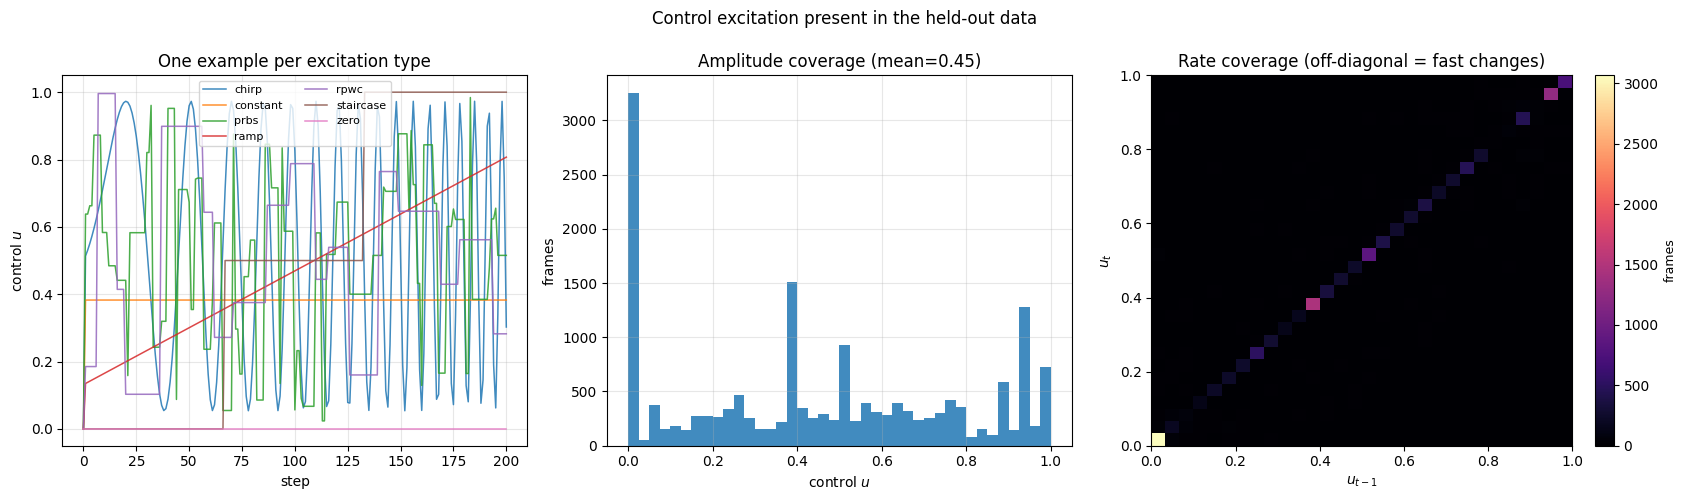

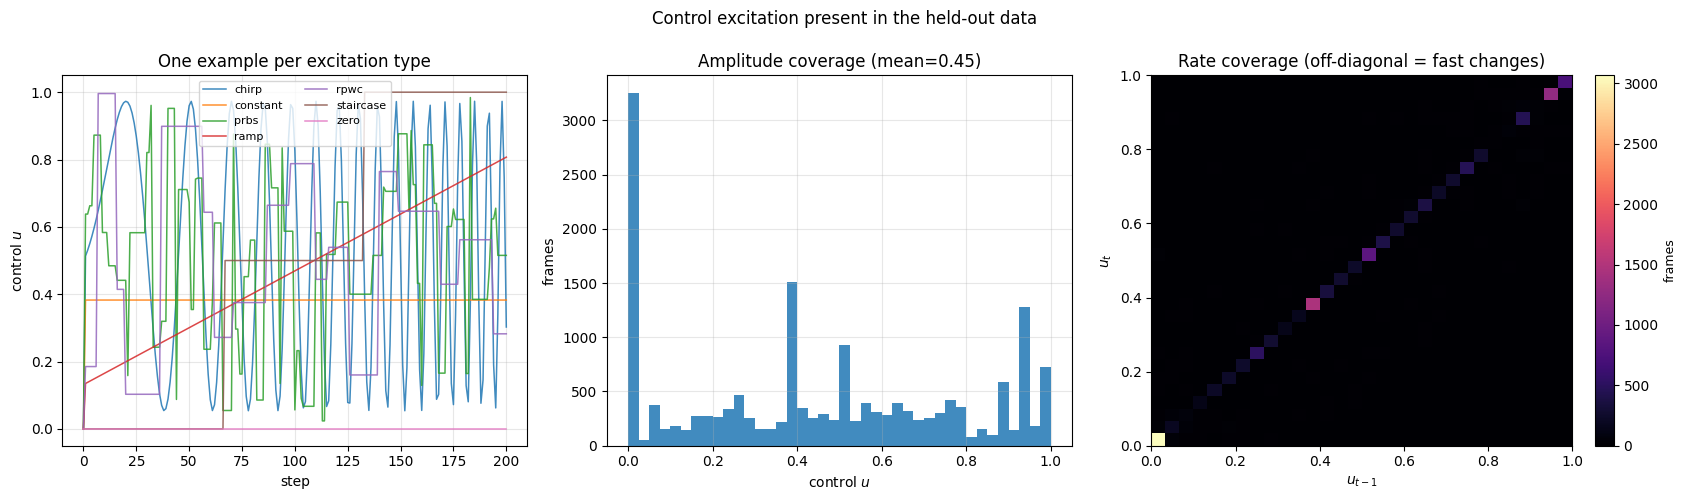

In [37]:
ep.fig_control_coverage(val)

## 3. Training curves

Losses over epochs, the full-vs-linear latent error, the regularizers, and the
linear-system diagnostics.

- `val_latent` rising while `train_loss` falls means the multi-step rollouts are being
  over-fit, so the best checkpoint is early.
- `vic_var` sitting at 0 is good: every latent dimension is clear of the variance floor,
  so the representation has not collapsed to a constant.
- `spectral_radius` drifting above 1 means the linear core has become unstable and long
  rollouts will diverge.

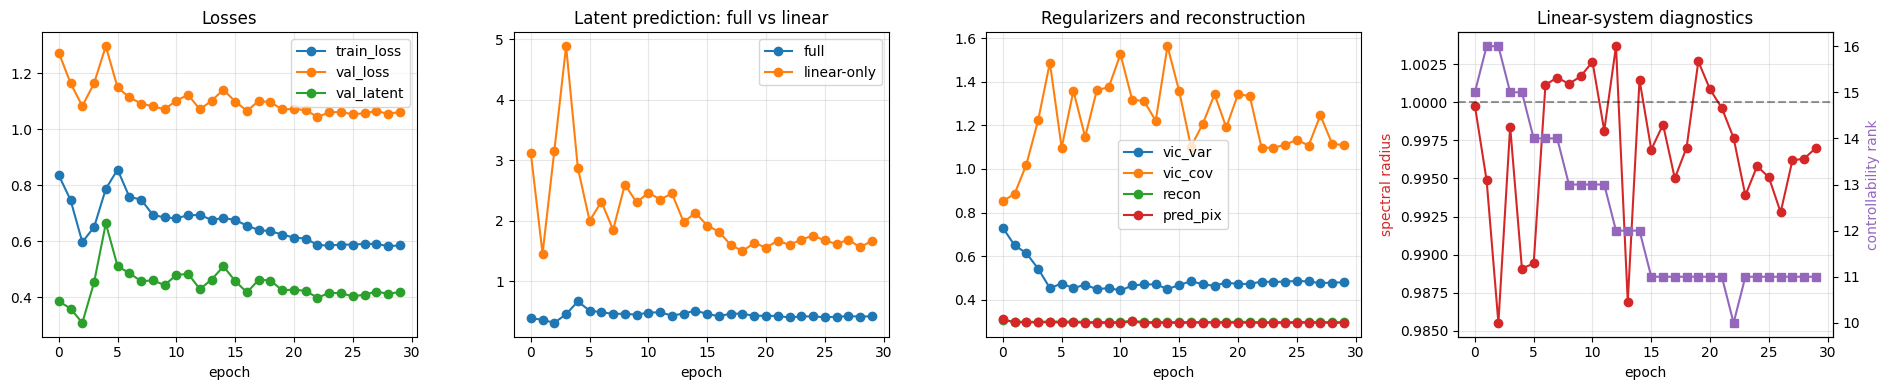

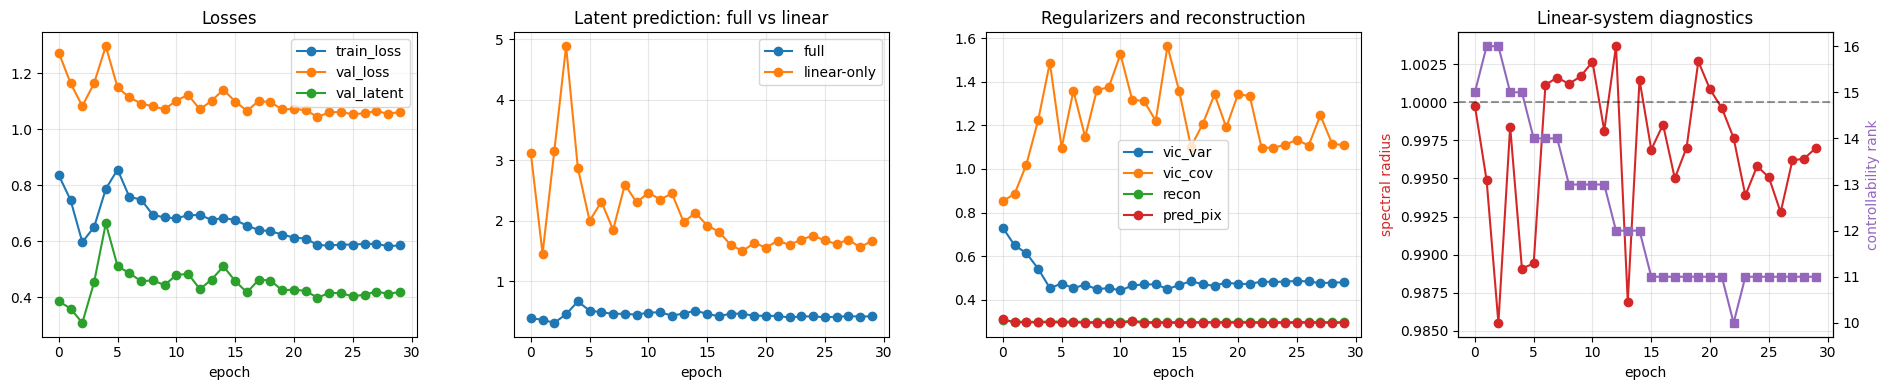

In [38]:
ep.fig_learning_curves(METRICS)

## 4. Prediction accuracy, against baselines

A raw latent MSE means nothing on its own — the latent has no units and its scale is set
by the VICReg variance target. Four curves make it readable:

| curve | what it is |
|---|---|
| **full dynamics** | the model's actual update, `Az + Bu` plus the nonlinear residual |
| **model linear core** | the same learned `A`, `B` with the residual switched off |
| **best linear fit (DMDc)** | a linear operator fitted by least squares to *this* latent |
| **persistence** | freeze the initial latent, `ẑ_k = z_0` |

Two comparisons carry all the information. **Full vs persistence** asks whether the
model learned any dynamics at all; losing to a frozen latent means it did not. **Full vs
best-linear-fit** is the sharper test, and it separates two explanations that the
training-time `linearity_gap` metric confuses:

- If the fitted linear model *matches or beats* the full model, the latent is
  effectively linear and the model's own `A`/`B` are simply undertrained. Linear control
  tools apply — good news.
- If the fitted linear model is clearly worse, the latent genuinely needs the nonlinear
  residual.

The right panel converts MSE to variance explained (`1 - mse/var`), where 1.0 is perfect
and 0.0 is no better than always guessing the average latent.

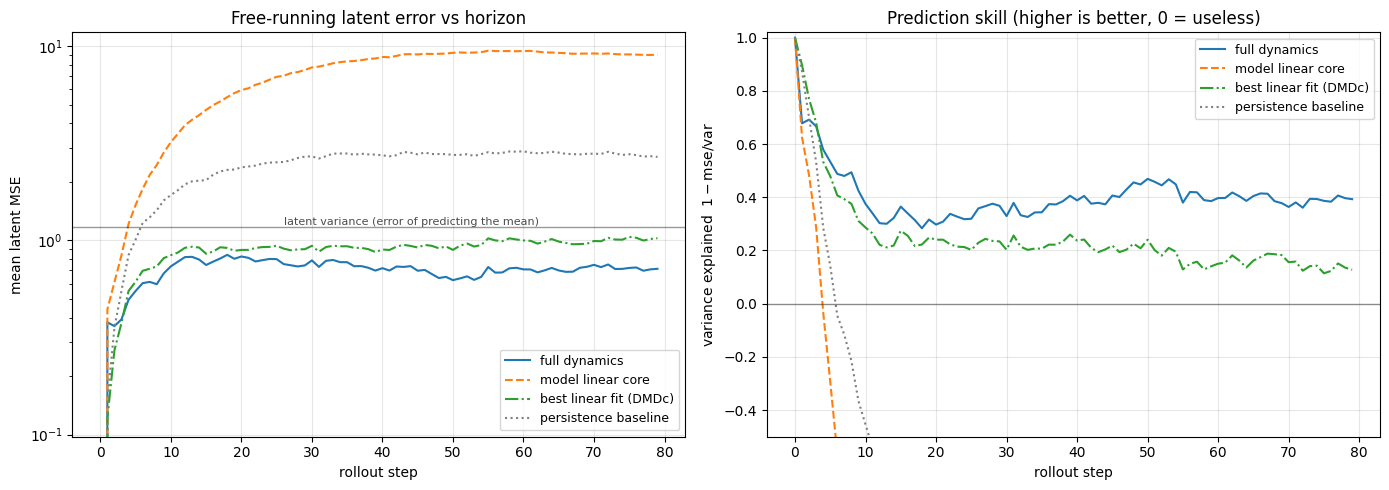

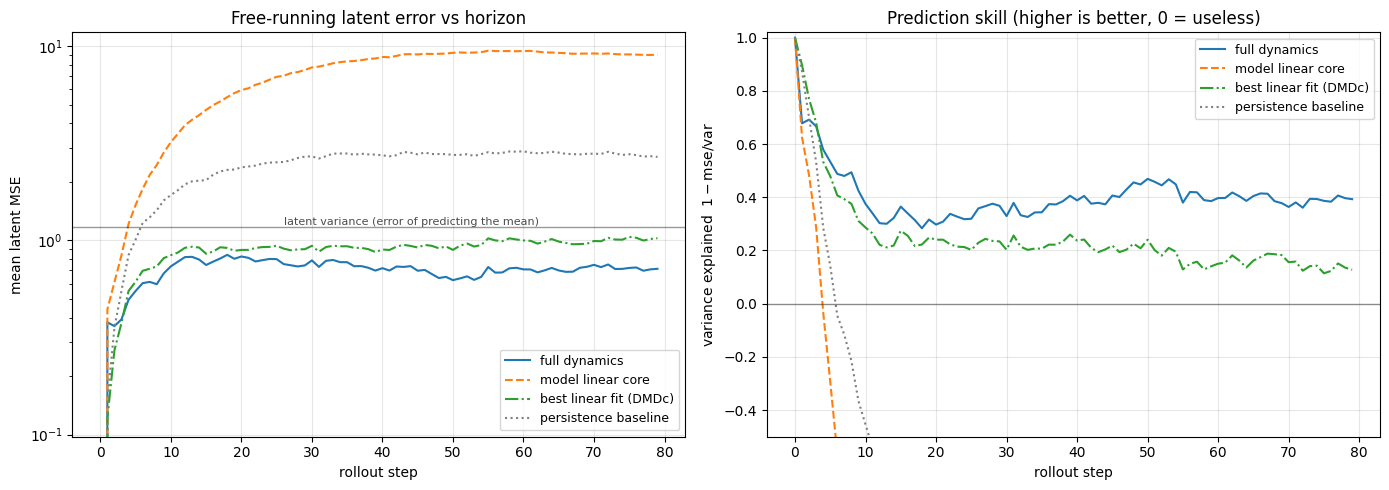

In [39]:
ep.fig_horizon_errors(herr, max_step=80)

## 5. Pixel space: what the model sees and what it imagines

### 5a. Reconstruction — the encoder/decoder bottleneck alone

Encode a real frame and decode it straight back, with no dynamics involved. This isolates
how much the bottleneck preserves.

Expect the decoded channels to look soft: the decoder outputs an occupancy
*probability* per cell, not a binary map, and the encoder's global average+max pooling
deliberately discards where individual agents are. Judge the total mass in each title
and the coarse spatial pattern, not the crispness. Each row is scaled to its own maximum
(printed in the row label) because the decoded values sit well below 1.

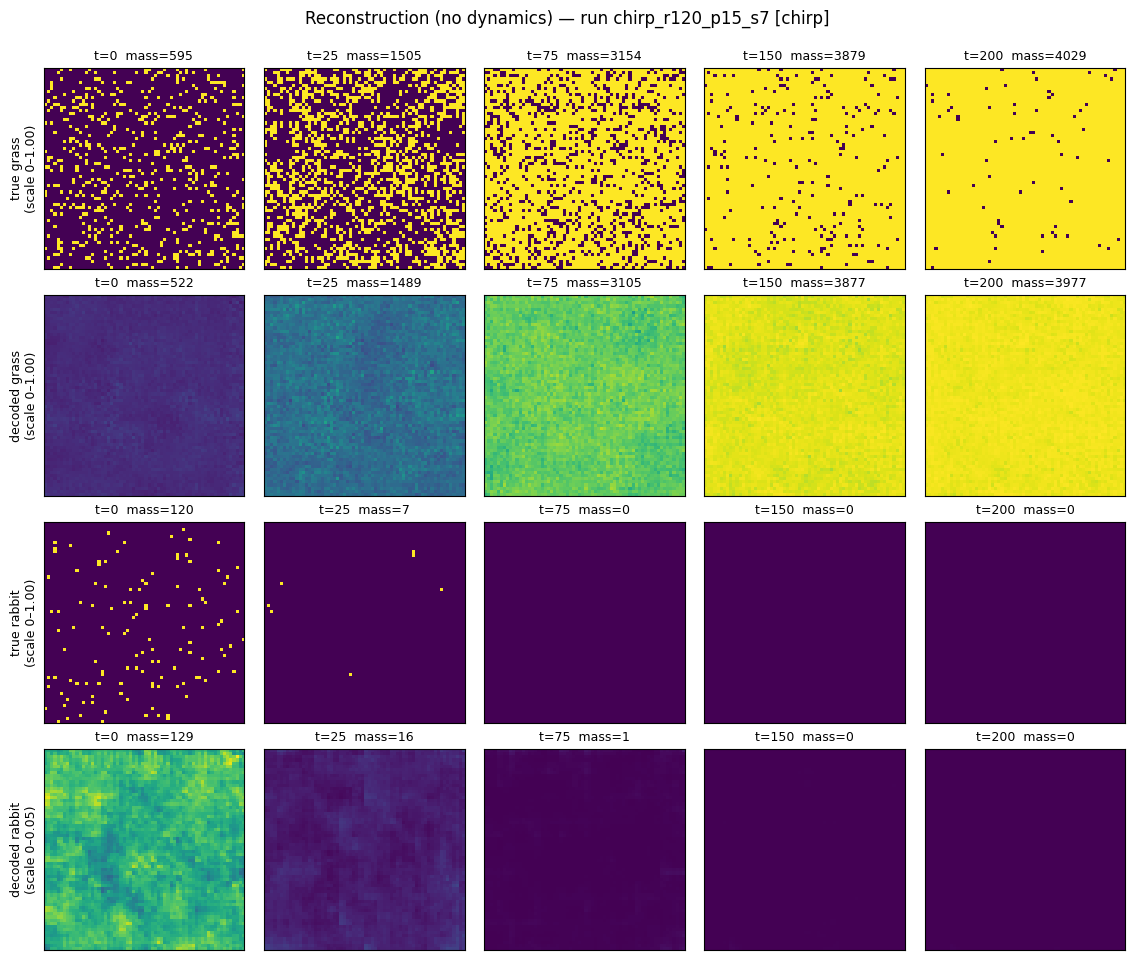

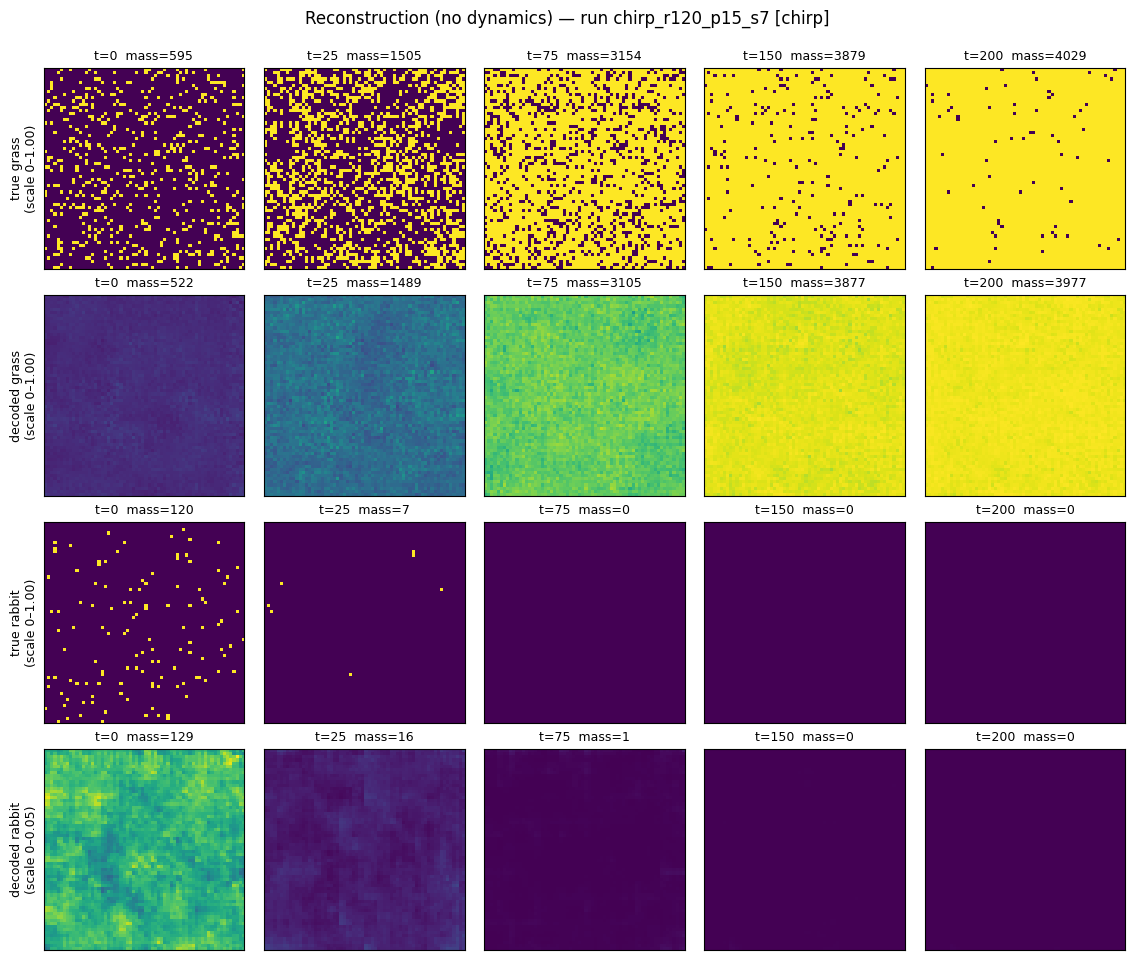

In [40]:
ep.fig_reconstructions(model, val[0], times=(0, 25, 75, 150, 200))

### 5b. Free-running imagination

Now only the first column is observed. Everything after it is predicted from the control
sequence alone, then decoded for display.

The prediction will blur into a diffuse density field as the horizon grows, and **that is
correct behaviour**, not a bug: individual agent positions are genuinely unpredictable, so
the best possible forecast is a probability of occupancy. Compare the `mass=` numbers
across the true and predicted rows — tracking those is the real test. The failure modes
to watch for are mass collapsing to zero, mass saturating the grid, or the field going
completely uniform while the truth still has structure.

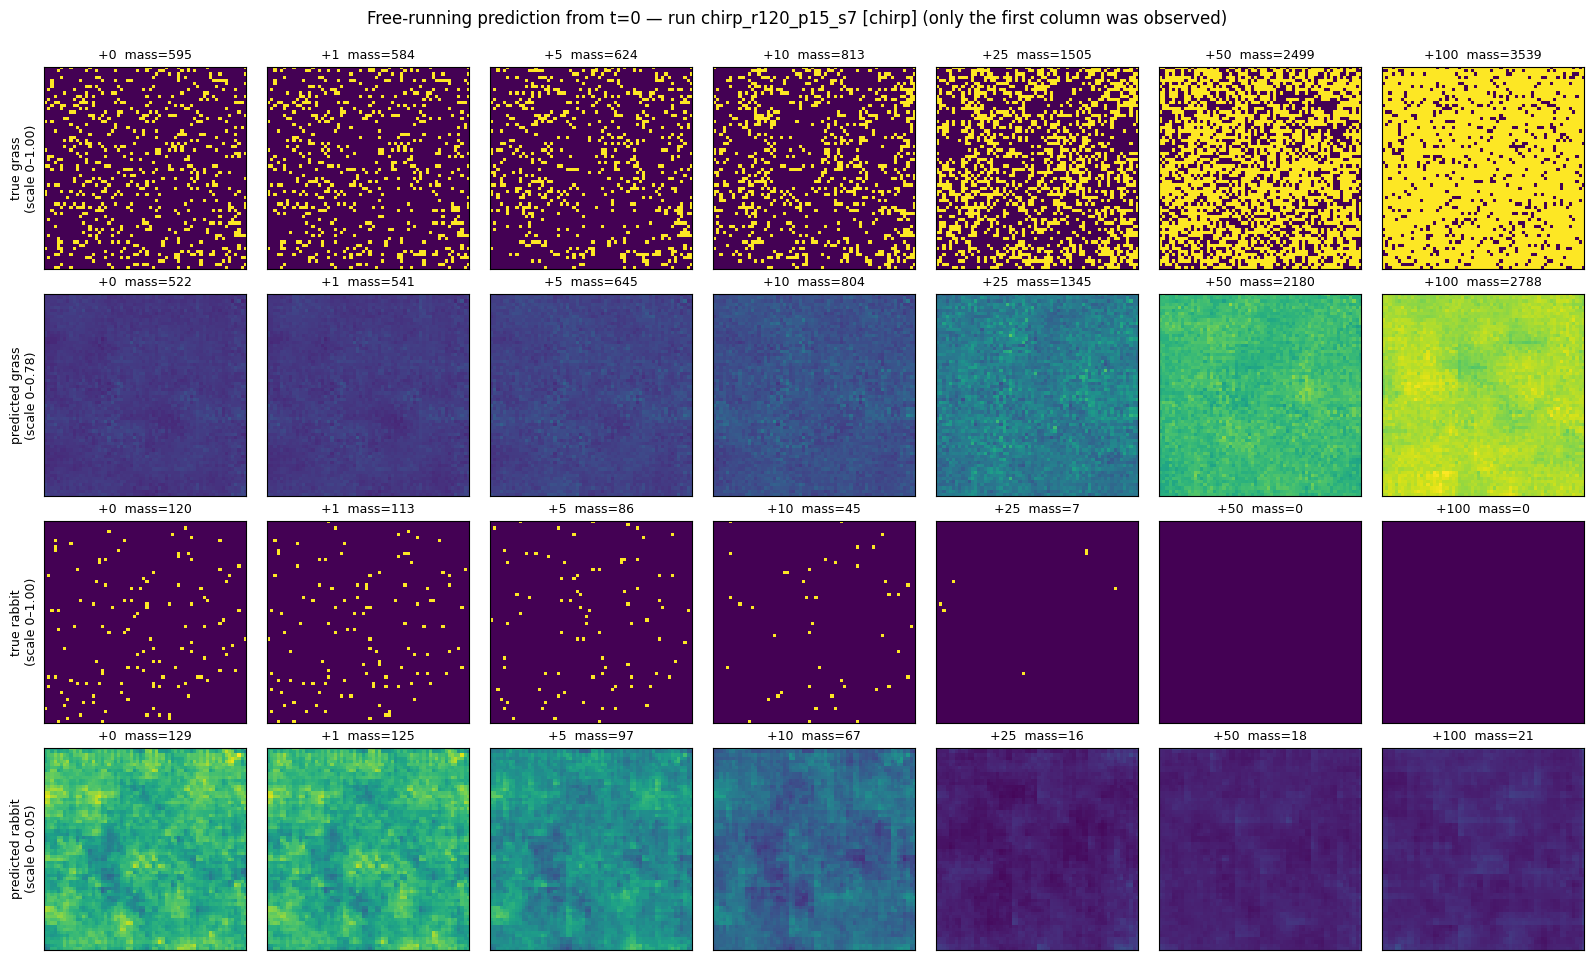

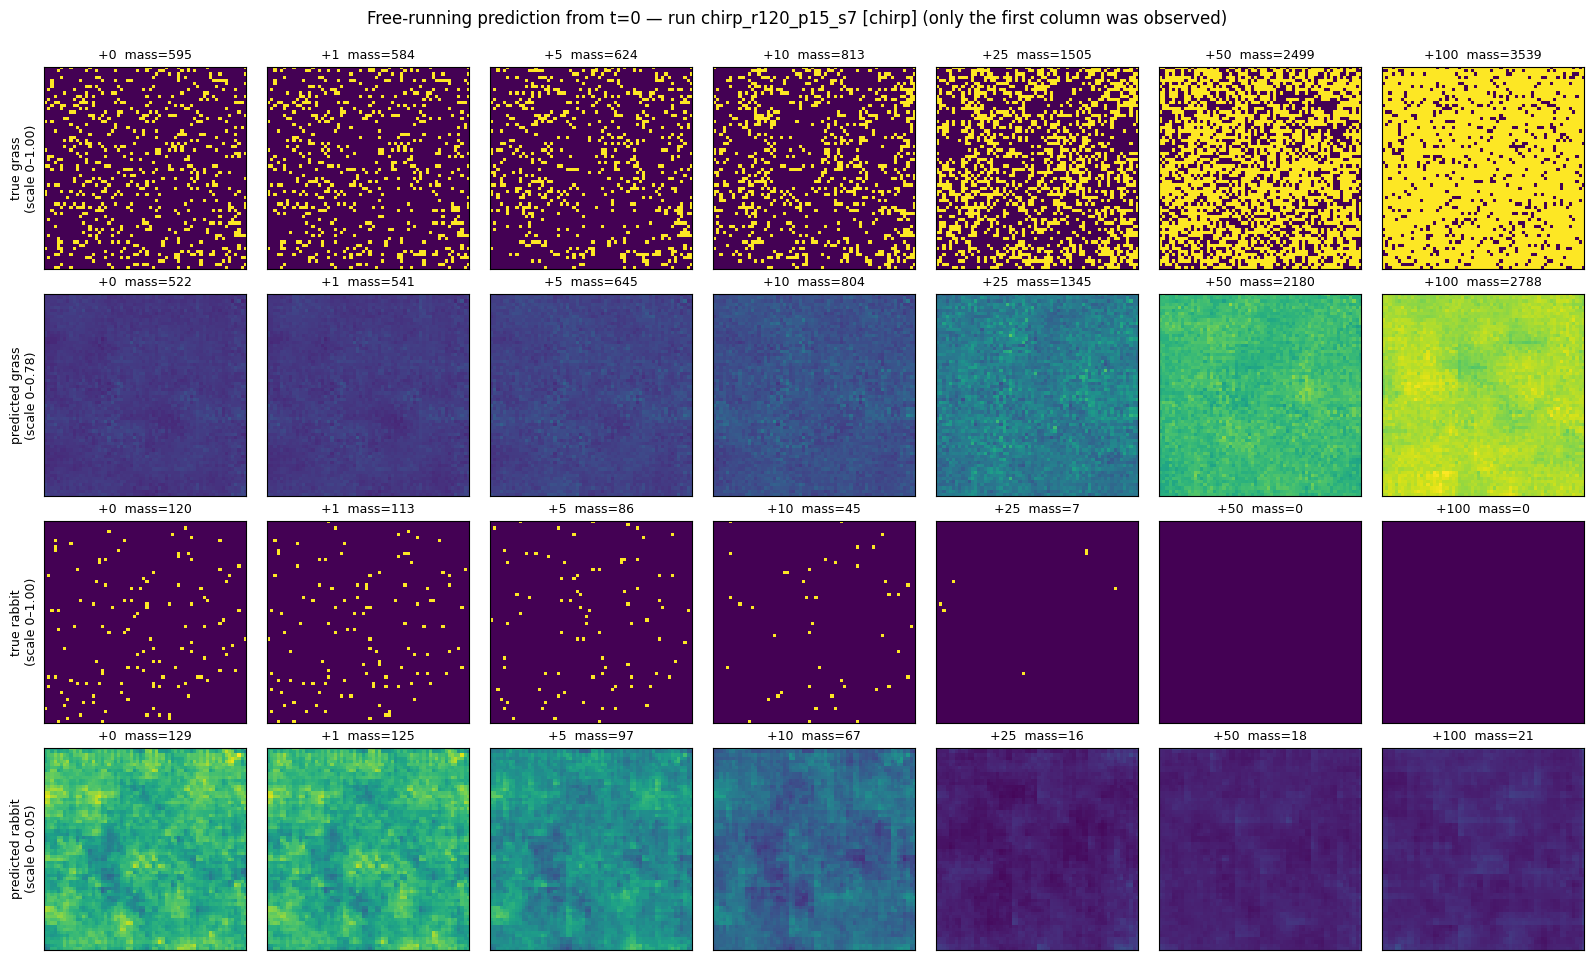

In [41]:
ep.fig_prediction_frames(model, val[0], start=0, horizons=(0, 1, 5, 10, 25, 50, 100))

## 6. Is the latent a usable state?

This is the section that decides whether the whole approach is viable, because a
controller acts on the latent. Three questions: does it have structure, is it using its
capacity, and can you read the quantities you care about out of it?

### 6a. Geometry

The same point cloud (top two principal components of every encoded held-out frame)
colored four different ways. A smooth gradient means that quantity lives in the latent's
dominant directions — exactly what a controller needs. Salt-and-pepper coloring means
the quantity is absent or buried in minor directions.

The bottom-middle panel draws individual runs as paths: coherent trajectories mean the
latent evolves smoothly, while a scribble means the encoder is tracking per-frame agent
jitter. The bottom-right panel is the capacity check — the **participation ratio** is a
smooth count of how many dimensions are genuinely in use. A ratio far below the nominal
latent dimension means most dimensions are redundant copies, which is partial
representation collapse and an argument for either a smaller latent or a stronger
covariance penalty.

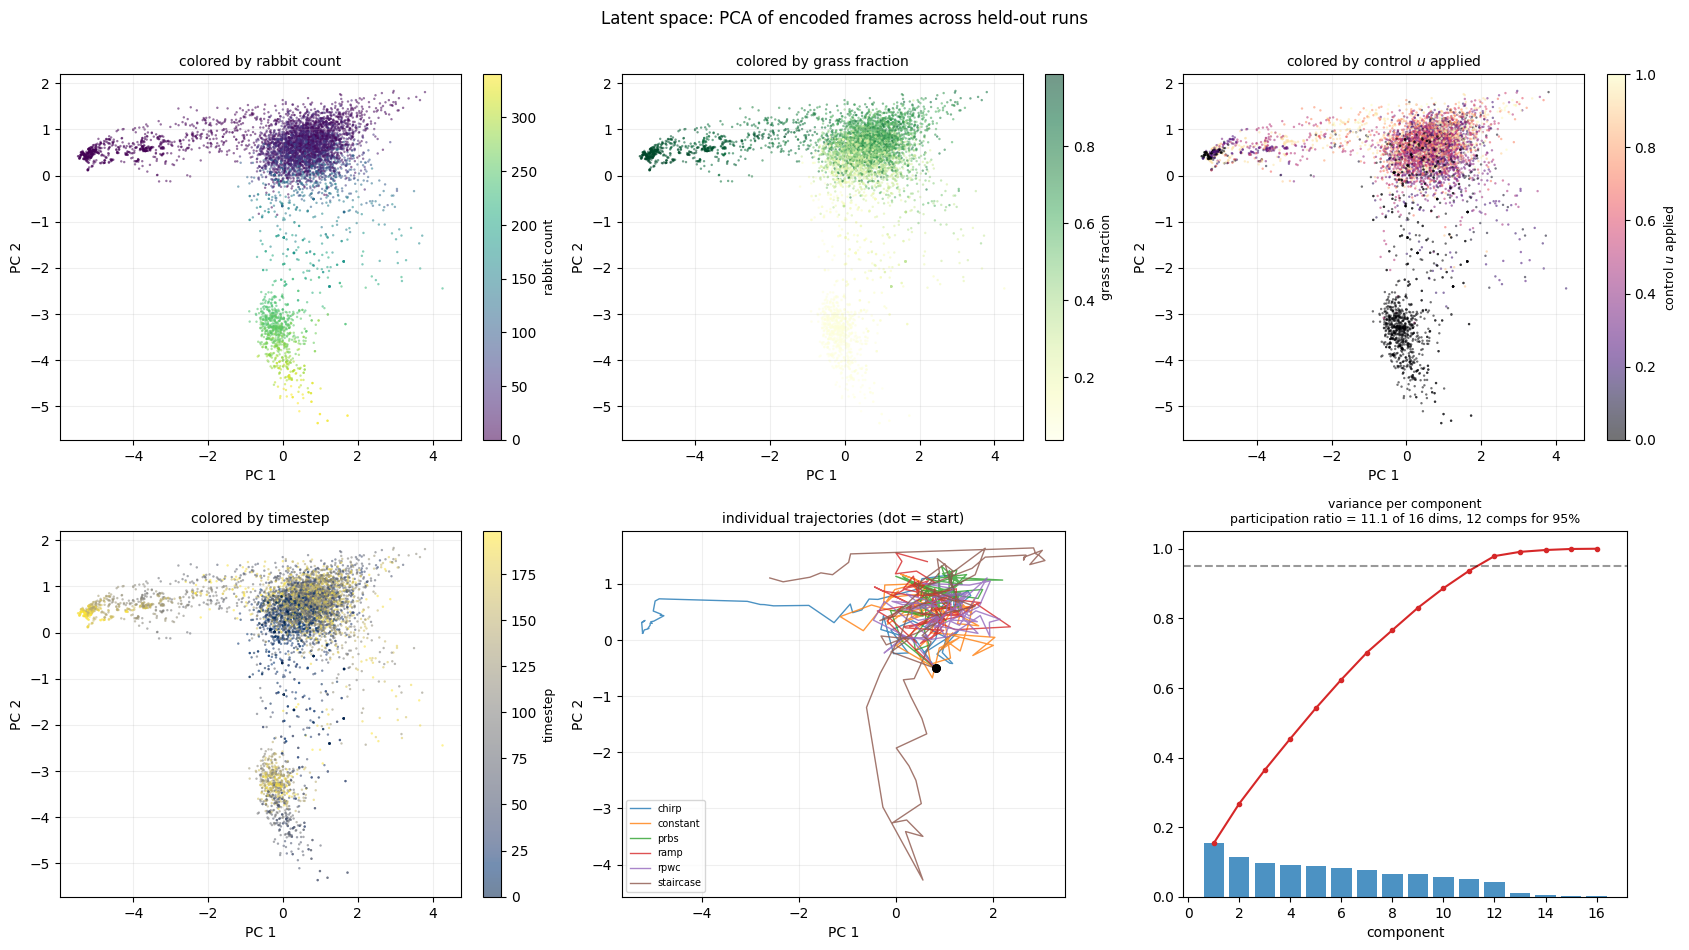

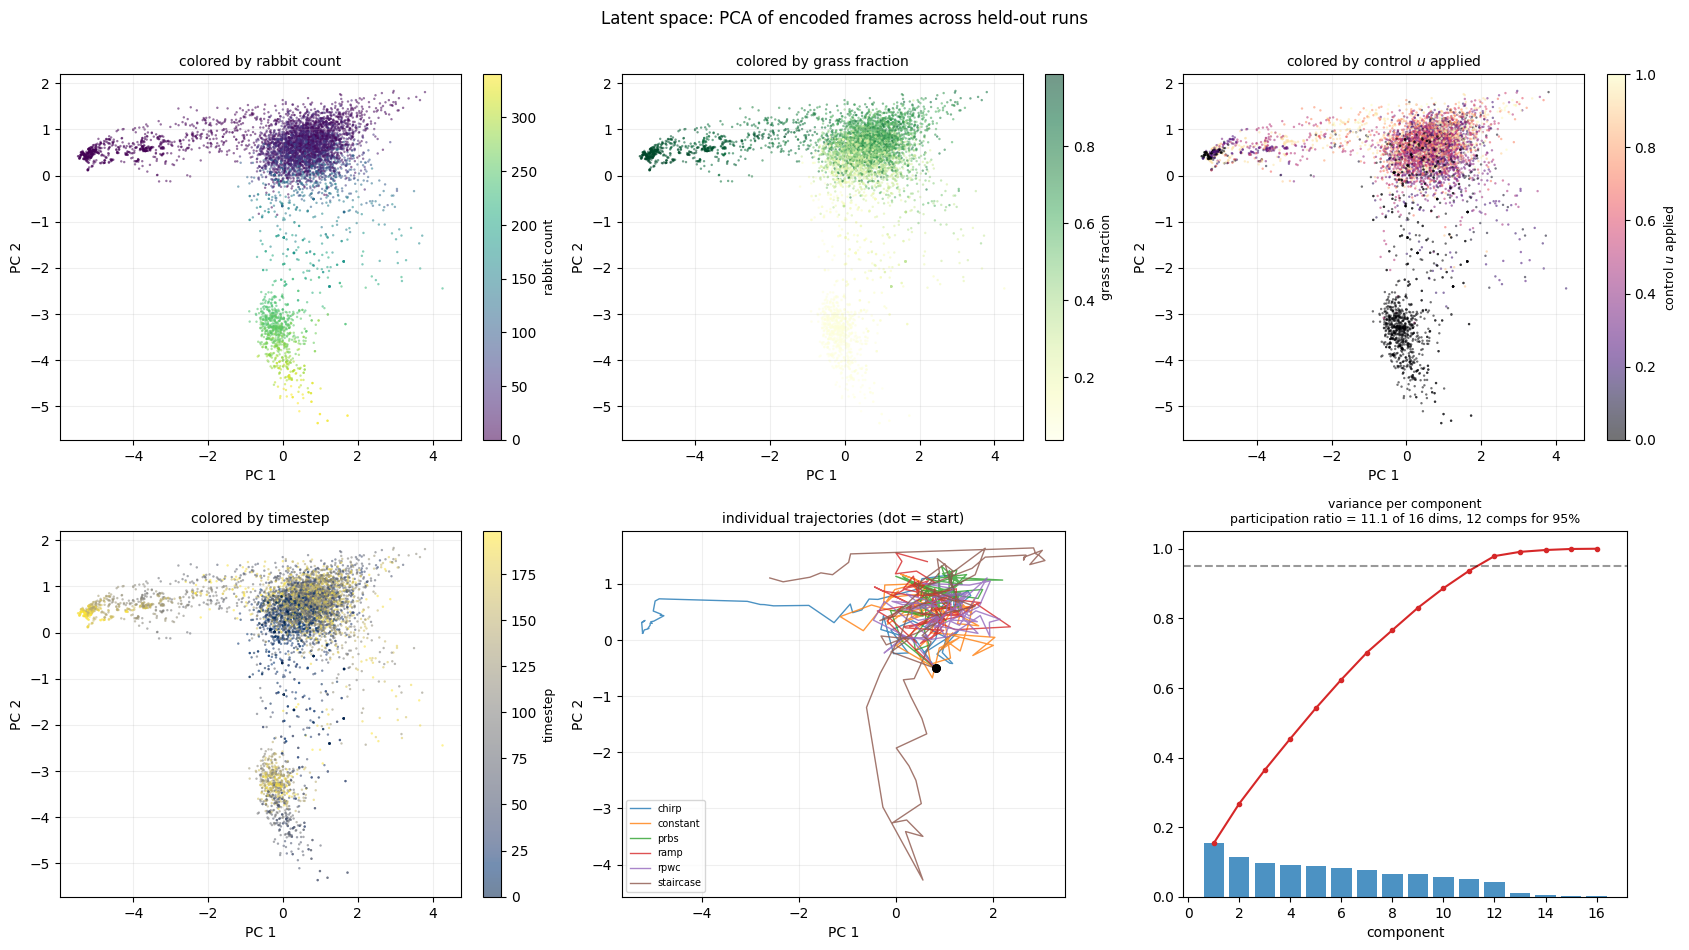

In [42]:
ep.fig_latent_pca(pca, stride=3, n_traj_lines=6)

### 6b. What can be linearly read out of the latent?

Ridge regressions fitted on the train split from `z` to each ground-truth quantity,
scored on held-out data. This is the most direct possible answer to "did the encoder keep
what matters".

`rabbit_count` near 1 is the key result: it means the population you want to regulate is
a *linear function* of the latent, so a linear controller can target it directly and you
do not need the decoder in the control loop at all. `u_applied` is a different kind of
check — it asks whether the control that produced a frame leaves any visible trace. Low
values there are expected (culling 10% of rabbits barely changes one image) but very low
values mean the encoder is discarding the actuator's signature.

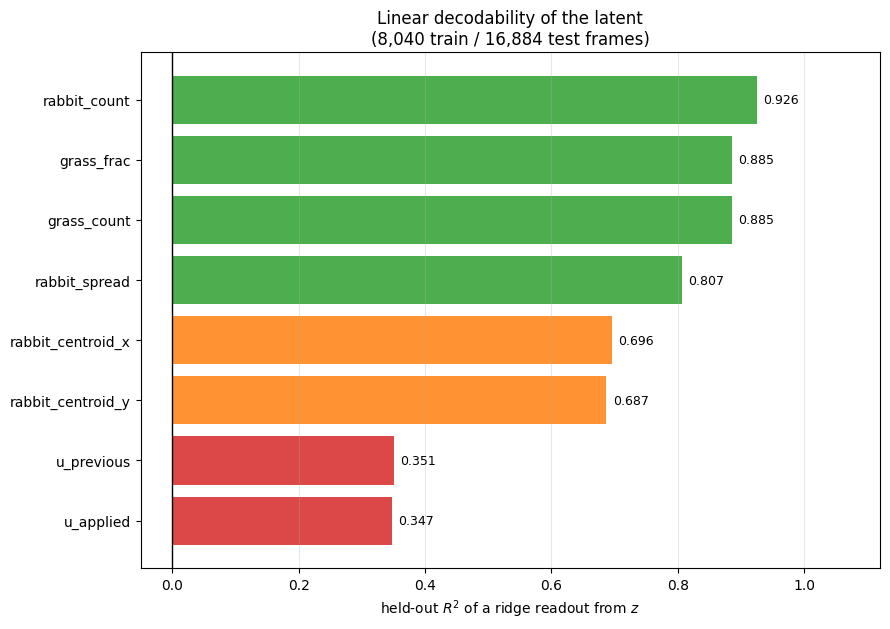

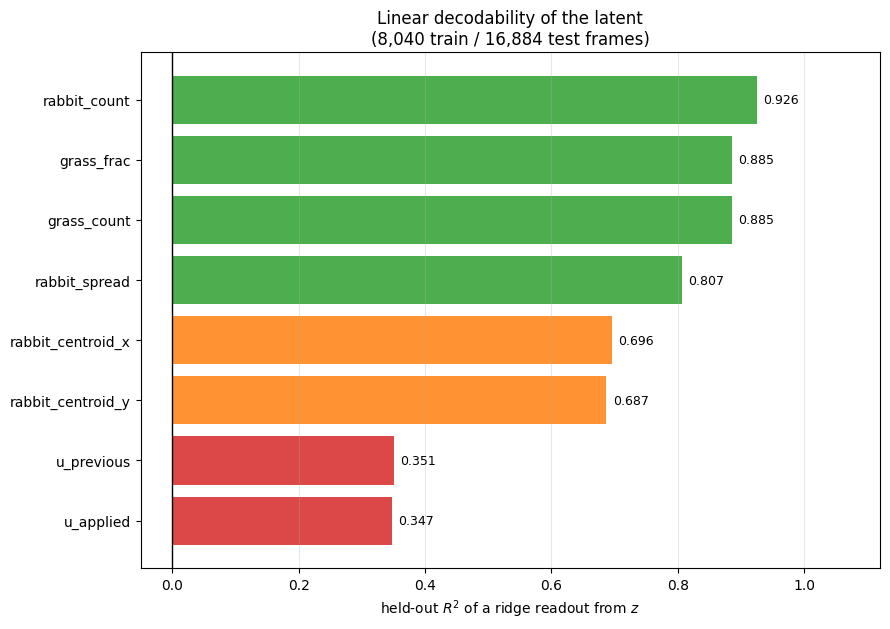

In [43]:
ep.fig_latent_probe(probe)

### 6c. Individual latent dimensions over time

The highest-variance dimensions for one run: encoded truth against the free-running
prediction, both full and linear-only.

Smooth encoded traces mean the encoder is extracting a slow macrostate out of noisy
frames — which is what you want, and what makes the dynamics learnable. Jagged traces
mean it is tracking frame-to-frame agent jitter, which is unpredictable by construction
and puts a hard ceiling on achievable latent accuracy. Where prediction and truth
diverge tells you *which* directions the dynamics model is failing on.

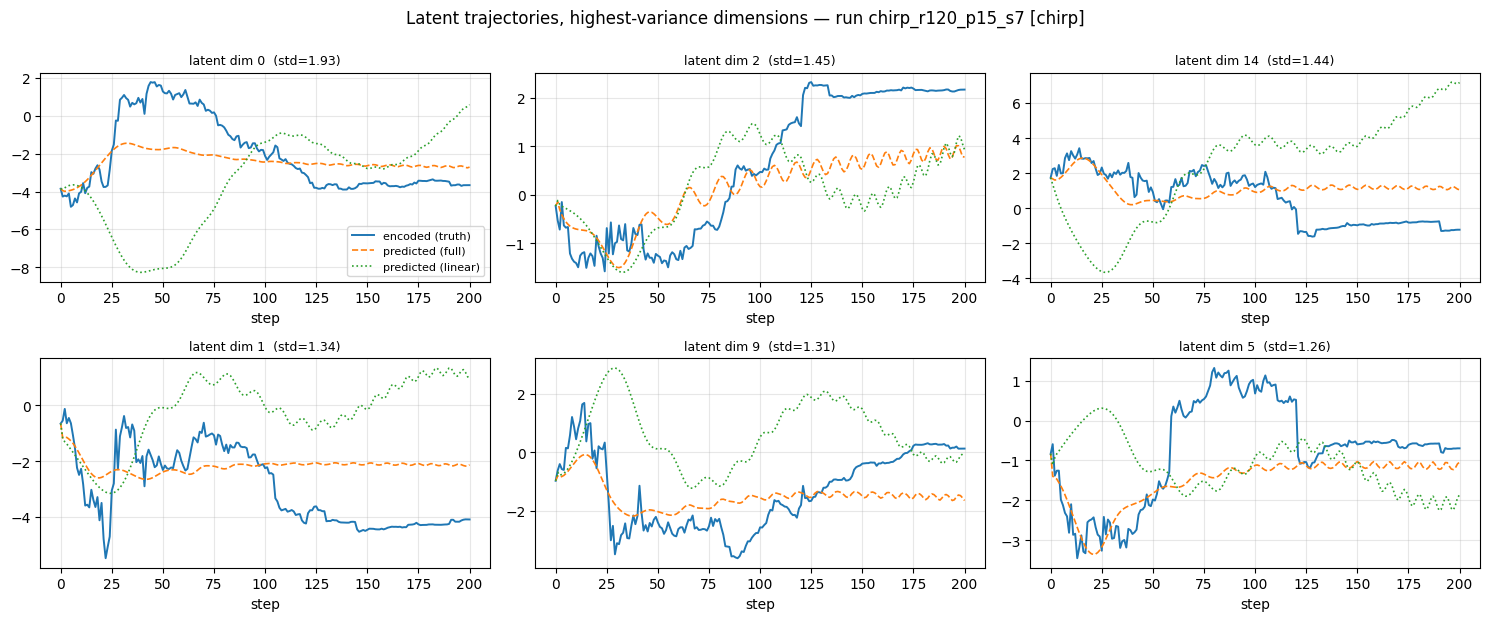

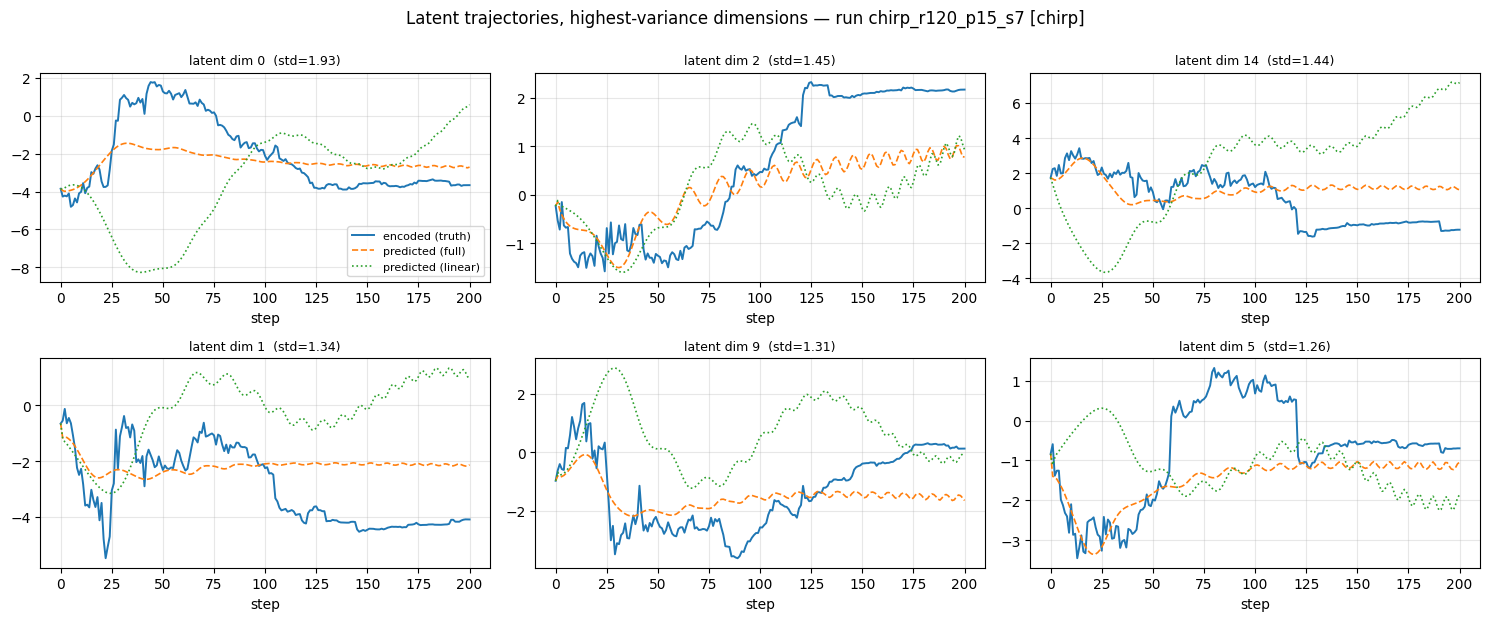

In [44]:
ep.fig_latent_traces(model, val[0], n_dims=6)

## 7. Macrostate rollout — the quantity you actually care about

Decoded occupancy mass from a free-running latent rollout versus the truth, for held-out
runs spanning different excitation types (control shaded in red). Rabbit mass on top,
grass on the bottom.

This is the pixel-noise-free version of section 5b: it ignores exactly where the agents
are and asks only whether the model tracks the population. A constant offset is far less
serious than a wrong shape — offsets are absorbed by feedback, but a model that misses a
collapse or invents an oscillation will mislead a controller.

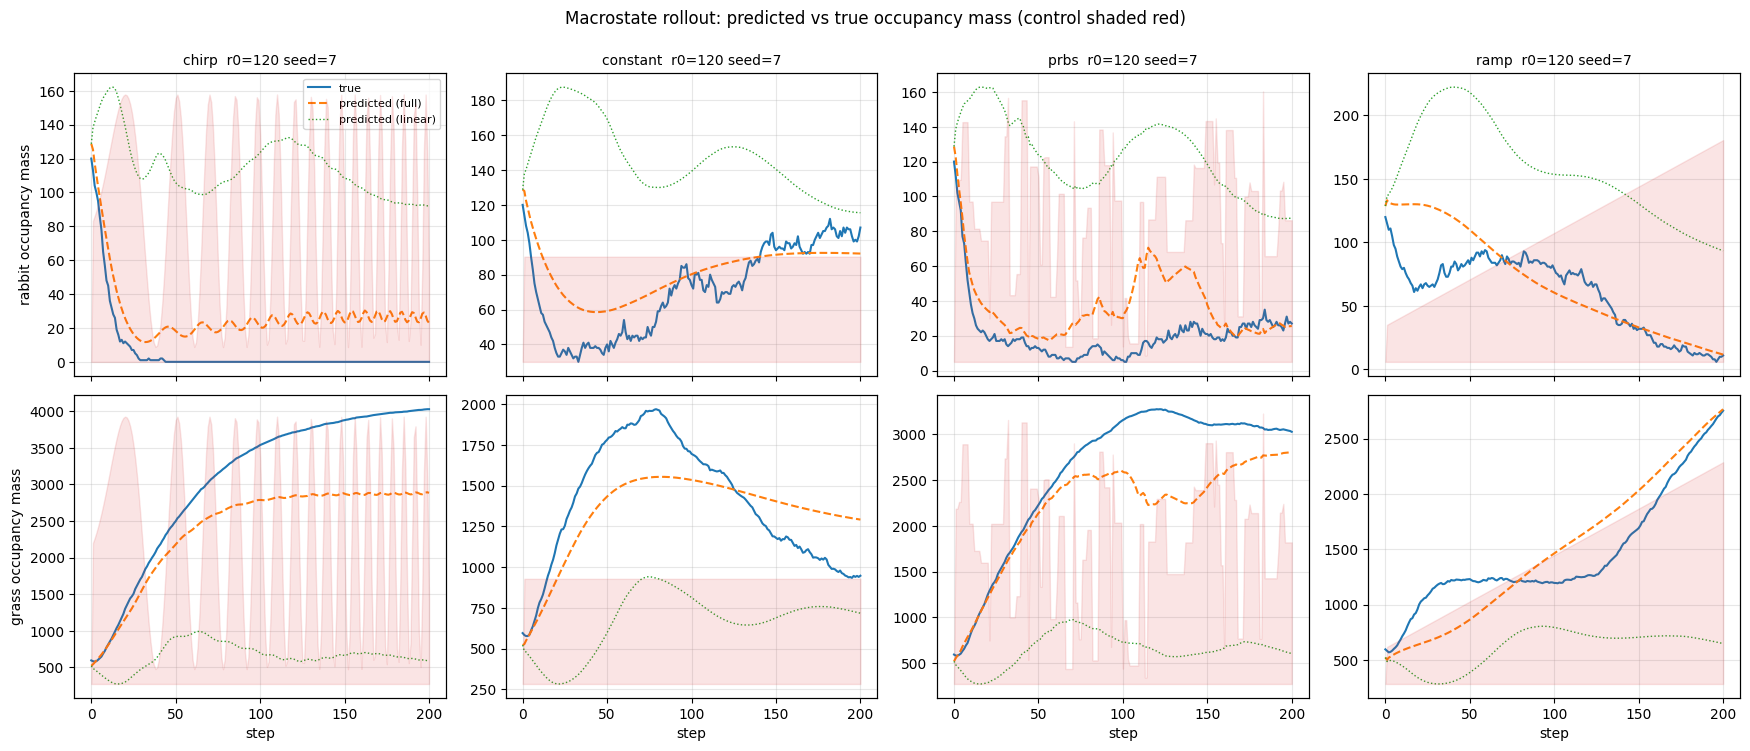

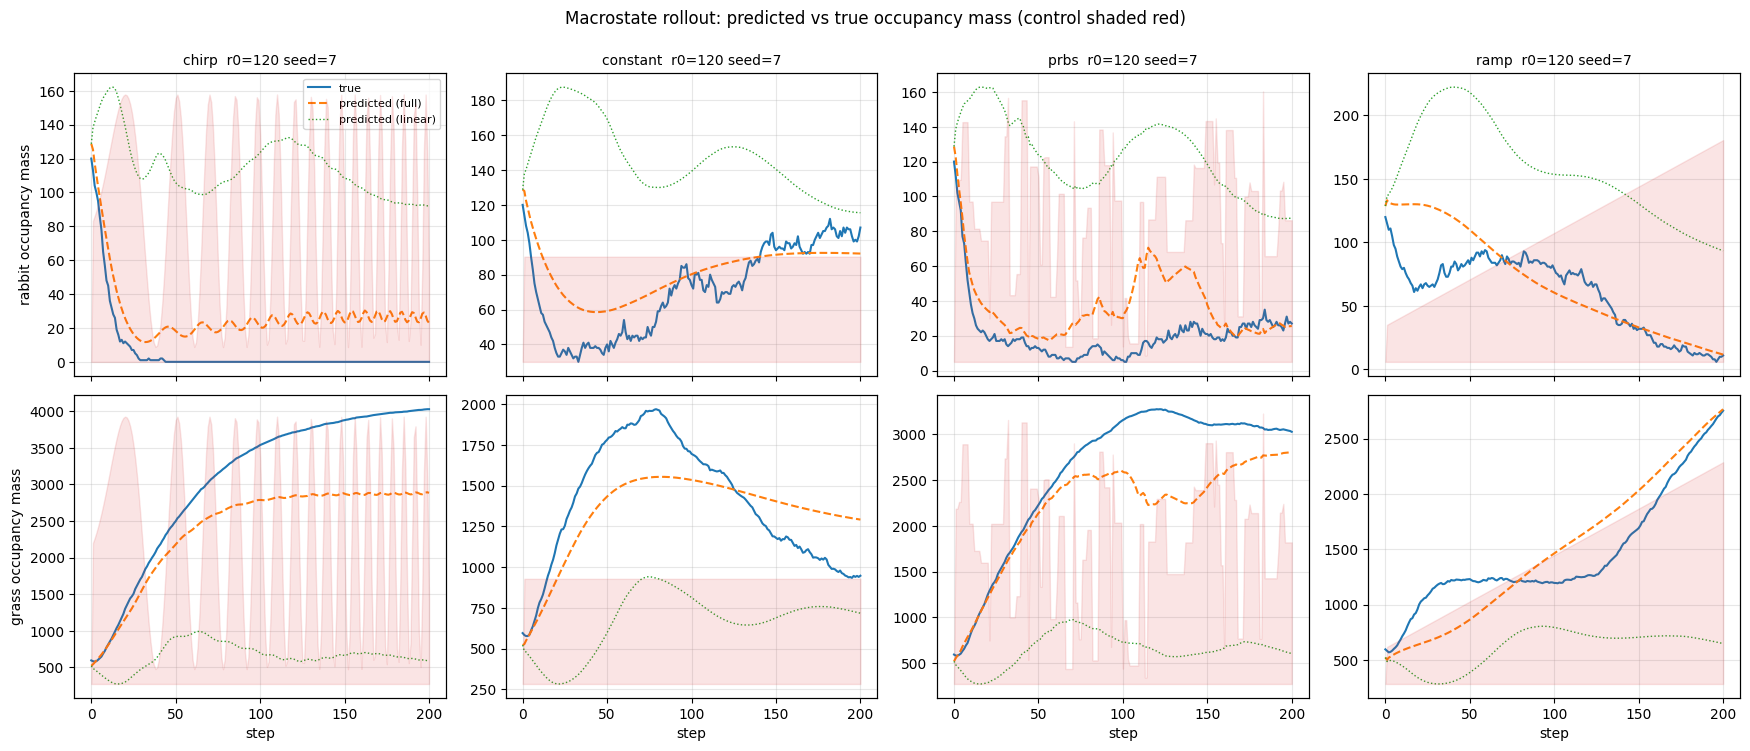

In [45]:
ep.fig_macrostate_rollout(model, val, n=4)

## 8. Does the model understand the control?

Prediction accuracy on logged trajectories can look fine while the model has learned the
control backwards, because most of a trajectory is explained by the natural dynamics.
These plots isolate the actuator by holding it constant and comparing against the real
simulator.

### 8a. Dose-response

Sustained cull level against the resulting population, model versus truth. The absolute
scales differ (decoded mass is a sum of probabilities, not a count), so the right panel
normalizes both to their `u = 0` value.

The hard requirement is **monotonicity**, reported as a Spearman correlation: −1 means
more culling reliably predicts fewer rabbits. Magnitudes can be miscalibrated and a
controller will still work; a scrambled ordering means it will push the wrong way.

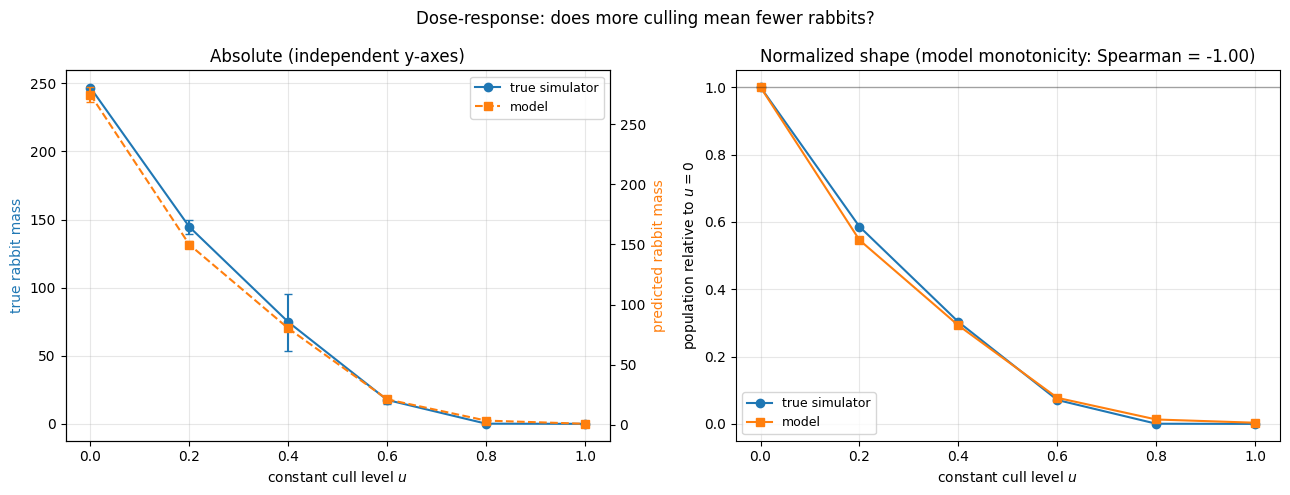

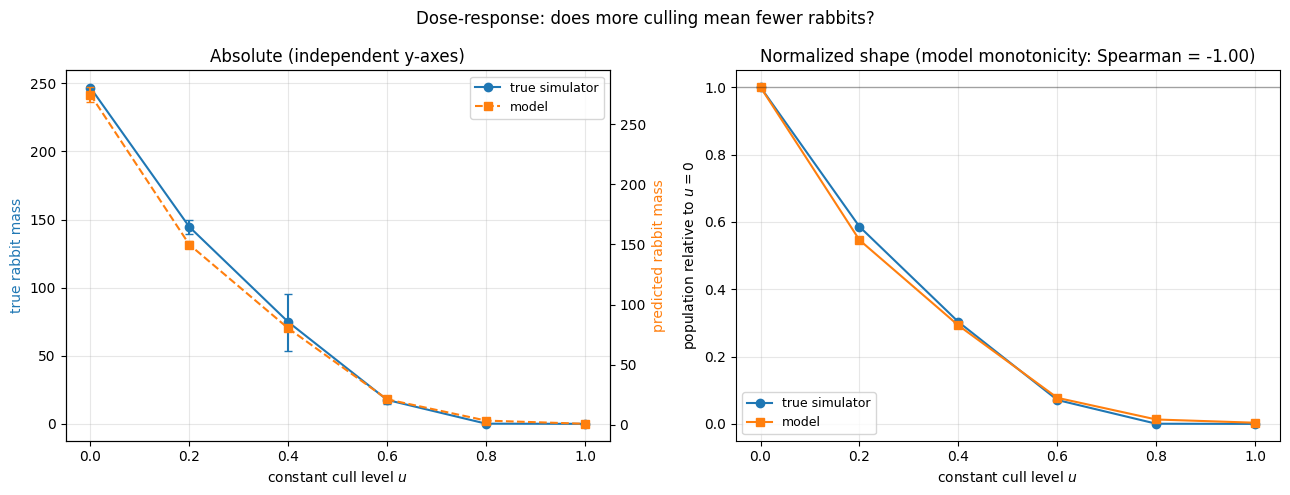

In [46]:
ep.fig_dose_response(dose)

### 8b. Control response over time

The same experiment before collapsing to a curve: the true simulator on the left and the
model on the right, under several constant cull levels from the same initial frame. Check
that the ordering of the curves matches and that the model's separation between levels
is not vanishingly small.

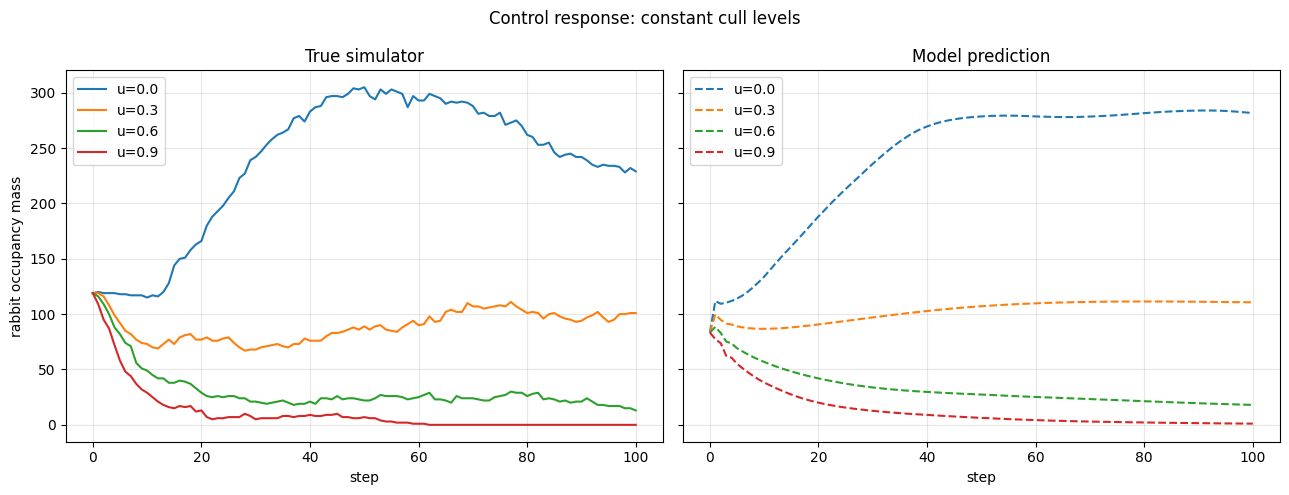

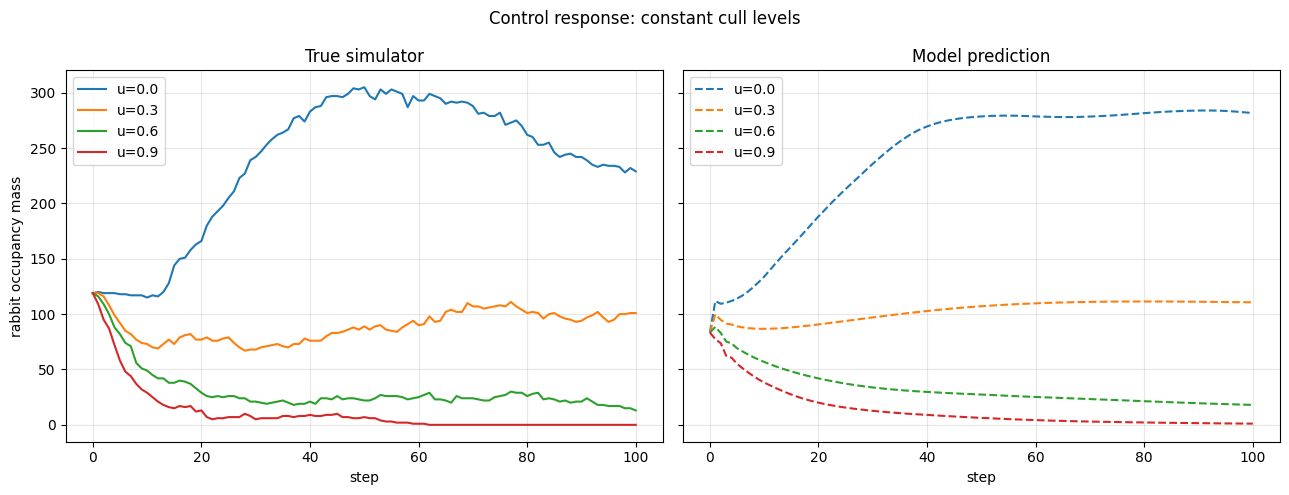

In [47]:
ep.fig_control_response(model, initial_rabbits=120, initial_grass_prob=0.35, steps=100)

### 8c. Step and impulse response

The textbook system-identification experiment, run on the learned model. Both panels show
the *deviation* from a zero-control rollout, so the curve is the control's own
contribution with the system's natural drift removed.

Three things to read: the **sign** (down, for culling), the **settling time** — how many
steps until the effect saturates, which sets how far ahead a controller must plan — and
whether curves for different `u` are spaced **proportionally**, which would mean the
actuator is linear and a single gain works at every amplitude. The dotted lines are the
linear core alone; where they track the solid lines, the linear model is sufficient.

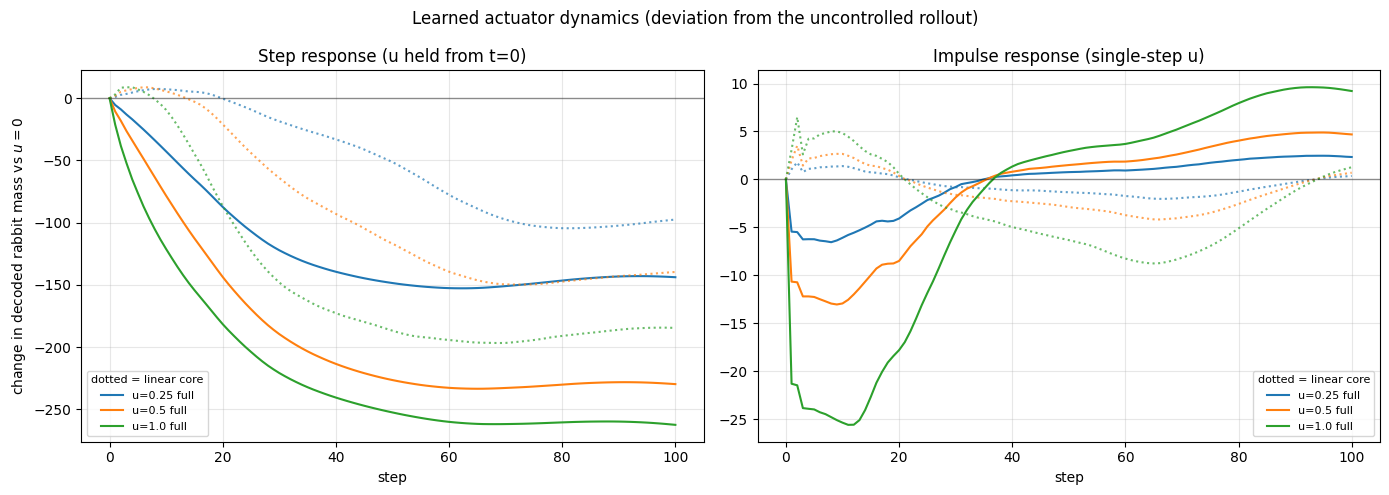

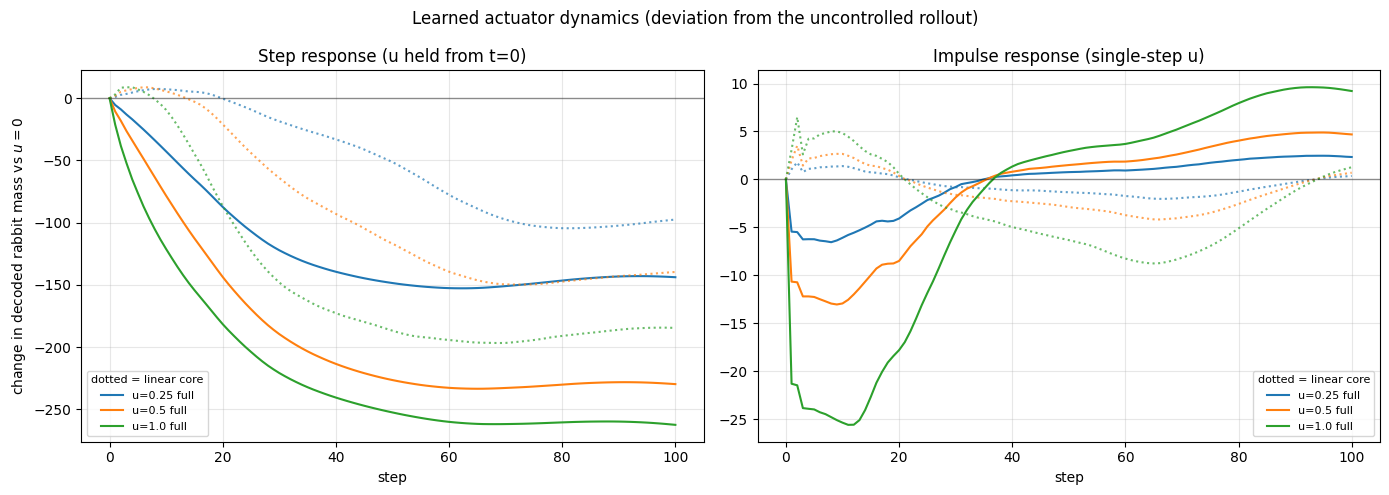

In [48]:
ep.fig_step_response(model, enc['z'][0, 0], steps=100)

## 9. Is the learned linear system fit for a controller?

`model.linear_system()` returns the `(A, B)` that LQR or linear MPC would consume, so it
is worth inspecting directly.

### 9a. Modes and reachability

`A`'s eigenvalues are the system's **modes** — independent patterns, each with its own
decay rate and oscillation period. Since rolling forward means multiplying by `A`
repeatedly, `|λ| < 1` decays, `|λ| > 1` grows without bound, and `|λ| ≈ 1` persists
almost indefinitely.

The left panel sizes and colors each mode by how strongly the actuator excites it (the
modal controllability test). The pattern to worry about is a marker **near the unit
circle** that is **dark**: a long-lived behaviour you cannot steer. The middle panel
converts `|λ|` into half-lives, which is the timescale a controller has to work on. The
right panel shows the singular values of the controllability matrix — the honest,
continuous version of the integer rank logged during training, since a direction you can
only reach with `1e-8` gain still counts toward that rank but is useless in practice.

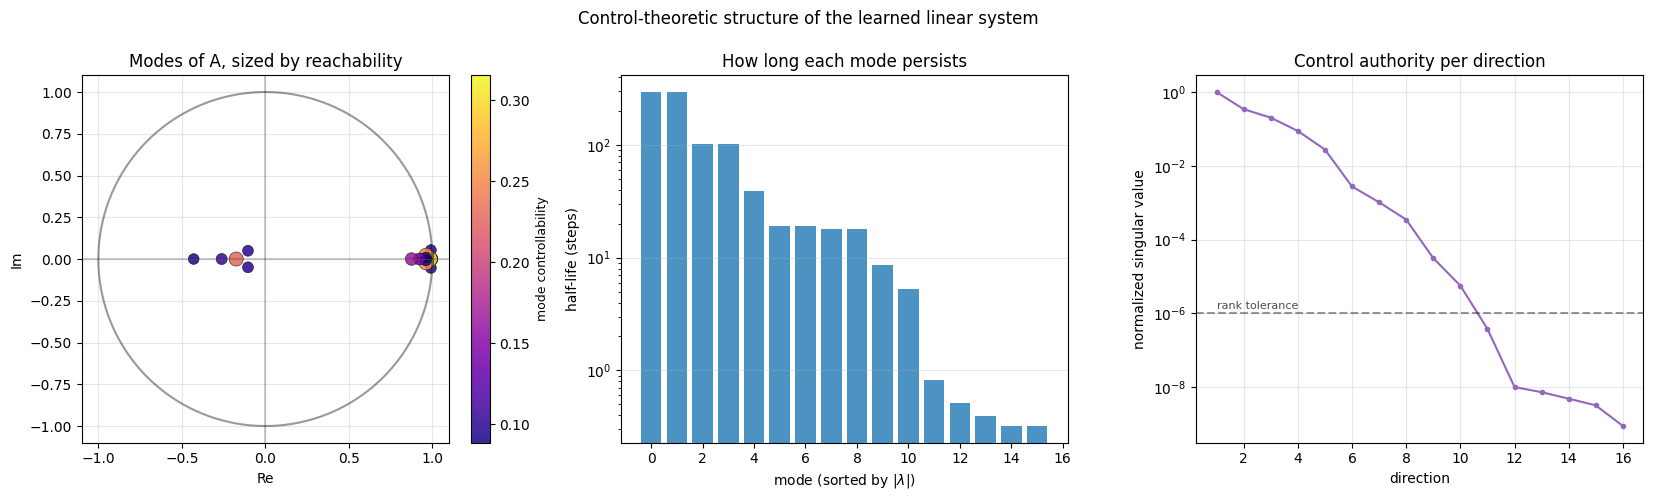

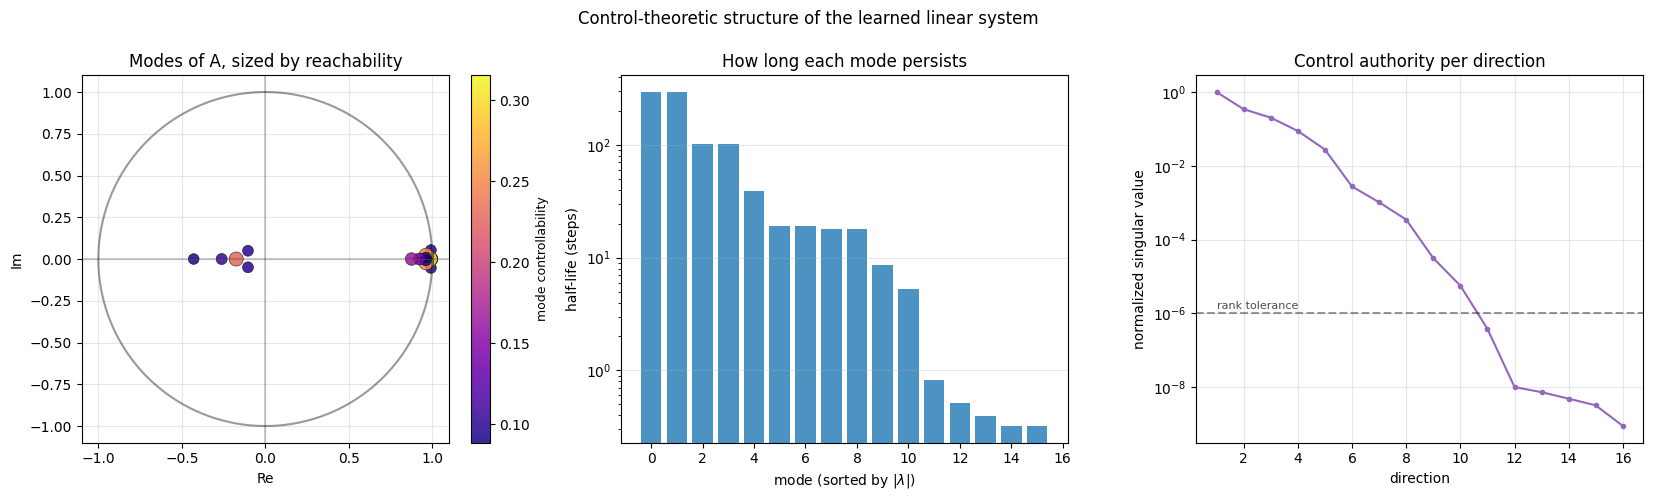

In [49]:
ep.fig_mode_map(modes, ctrl_sv)

### 9b. Where does the control act?

Left: the entries of `B`, i.e. which latent dimensions the actuator moves. There are two
columns because the simulator's cull has a one-step delay, so the model conditions on
`[u_t, u_{t−1}]`; a visible lag column confirms it learned the delay rather than assuming
instantaneous control.

Right: decode the latent before and after pushing it along the control direction `B·u`.
This makes the learned actuator visible in pixel space. The rabbit change map should be
predominantly **blue** (fewer rabbits) — and grass turning **red** is a bonus, since
fewer rabbits really should mean more surviving grass. If instead the control mostly
repaints grass or shifts the whole image uniformly, the model has attributed the actuator
to the wrong thing and the `B` matrix will mislead a controller.

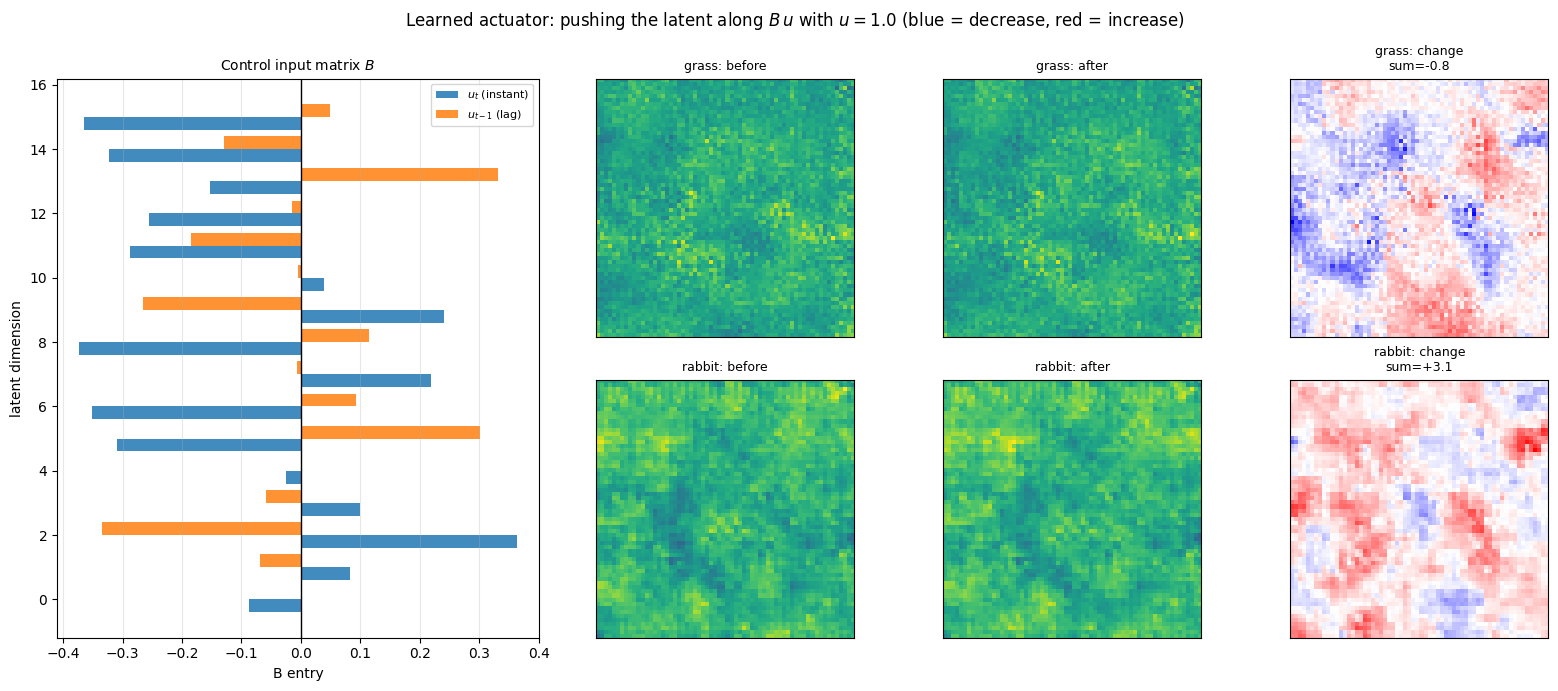

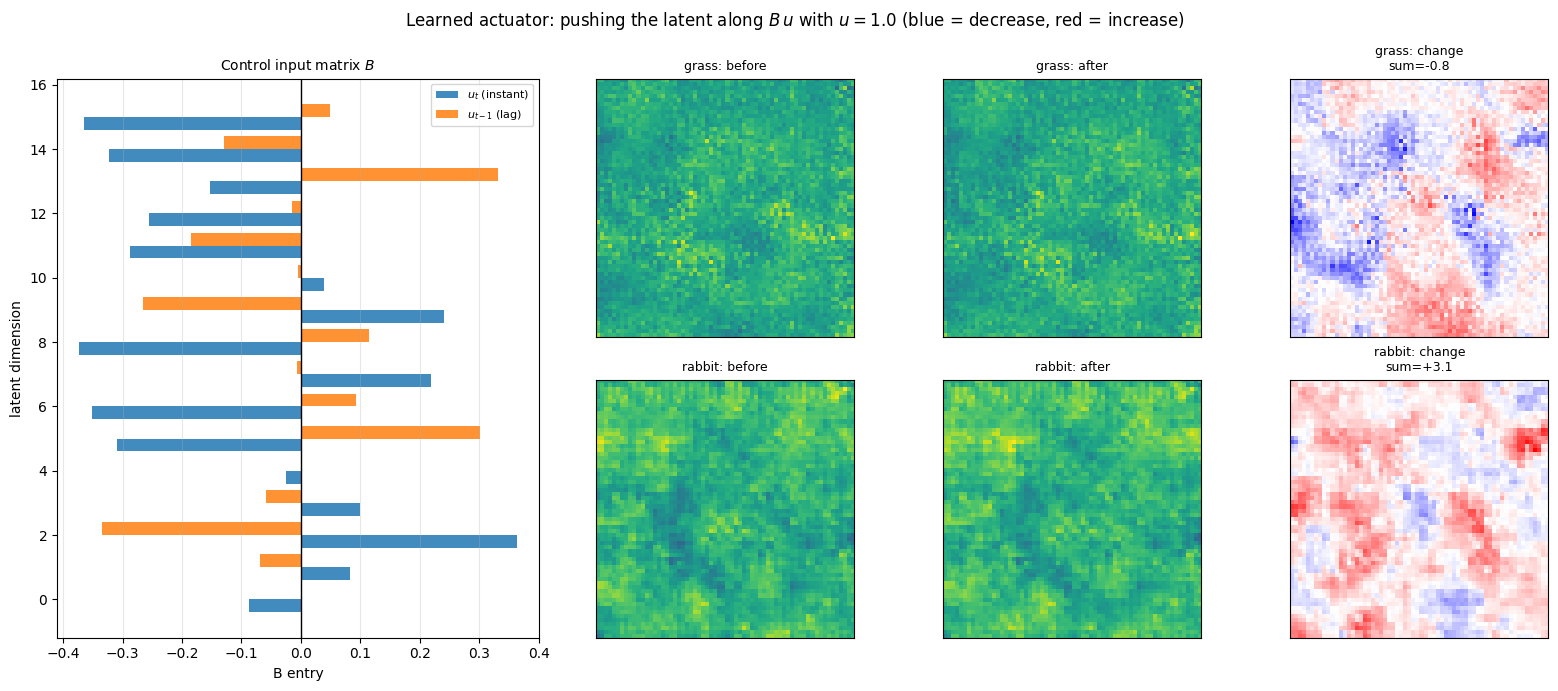

In [50]:
ep.fig_control_direction(model, enc['z'][0, 0], u=1.0)

## 10. Held-out test split

Everything above uses the validation split, which guided checkpoint selection. Re-scoring
on the untouched test split is the honest number. The dataset also tags out-of-
distribution runs (unseen excitation types, unseen initial conditions), so a gap here
against section 1 indicates over-fitting to the validation runs rather than a real
generalization failure.

In [51]:
enc_test = ev.encode_all(model, test)
herr_test = ev.horizon_errors(model, test, enc=enc_test, fitted=fitted)
macro_test = ev.macrostate_correlation(model, test, enc=enc_test)

h = min(SCORE_HORIZON, len(herr_test["steps"]) - 1)
print(f"{'':22s}{'val':>10}{'test':>10}")
for label, key in (
    (f"skill @ h={h}", "skill_full"),
    (f"linear core @ h={h}", "skill_linear"),
    (f"best linear @ h={h}", "skill_ls_linear"),
    (f"persistence @ h={h}", "skill_persistence"),
):
    print(f"{label:22s}{herr[key][h]:>10.3f}{herr_test[key][h]:>10.3f}")
print(f"{'rabbit mass corr':22s}{macro['rabbit_mass_corr']:>10.3f}"
      f"{macro_test['rabbit_mass_corr']:>10.3f}")

                             val      test
skill @ h=20               0.297     0.315
linear core @ h=20        -4.046    -4.724
best linear @ h=20         0.241     0.230
persistence @ h=20        -1.020    -1.070
rabbit mass corr           0.963     0.962


## 11. Reading the result

A checklist for turning the plots above into a decision:

**Did it learn dynamics?** Section 4, full vs persistence. If the model does not beat a
frozen latent at your horizon of interest, nothing else in the notebook matters.

**Is the latent worth controlling?** Section 6b. High `rabbit_count` R² means the
macrostate is a linear readout of the latent, which is the precondition for pointing a
controller at it. A participation ratio far below the latent dimension says the latent is
larger than it needs to be — shrink `--latent-dim` or raise the covariance weight.

**Linear or nonlinear?** Section 4, full vs best-linear-fit. If the fitted linear operator
keeps up, this latent is effectively linear and the training-time `linearity_gap` was
misleading — that metric compares against the linear core of a model trained *with* the
residual, so the core never had to stand on its own. The clean confirmation is to train a
separate model with `--dynamics-mode linear` and compare its `val_latent` against the
bilinear run.

**Can you steer it?** Sections 8 and 9. Monotonic dose-response and a control direction
that visibly acts on rabbits are the minimum. Then check that the slow modes near the
unit circle are also the reachable ones.

**Where to push next.** If prediction skill decays quickly while macrostate correlation
stays high, the model is fine at the aggregate level and the latent loss is being
dominated by unpredictable pixel jitter — the fix is on the target side (predict
observables directly, add an EMA target encoder, or smooth the frames into density
fields) rather than on the dynamics.